Pytorch is a numerical library that makes it very convenient to train deep networks on GPU hardware. It introduces a new programming vocabulary that takes a few steps beyond regular numerical python code. Although pytorch code can look simple and concrete, much of of the subtlety of what happens is invisible, so when working with pytorch code it helps to thoroughly understand the runtime model.

All the notebooks can be run on Google Colab where some GPU computation can be used for free, or they can be run on your own local Jupyter notebook server.

The examples should all work with python 3.5 or newer and pytorch 1.0 or newer.

In [1]:
import math
import numpy as np
import torch
from matplotlib import pyplot as plt

# Topic 1: Pytorch Tensors
The first big trick for doing math fast on a modern computer is to do giant array operations all at once.

To faciliate this, pytorch provides a torch.Tensor class that is a lookalike to the older python numerical library numpy.ndarray. Just like a numpy ndarray, the pytorch Tensor stores a d-dimensional array of numbers, where d can be zero or more, and where the contained numbers can be any of the usual selection of float or integer types. Pytorch is designed to feel just like numpy: almost all the numpy operations are also available on torch tensors. But if something is missing, torch tensors can be directly converted to and from numpy using x.numpy() and torch.from_numpy(a). So what is different and why did the pytorch authors bother to reimplement this whole library?

**There are two things that pytorch Tensors have that numpy arrays lack:**

1.   pytorch Tensors can live on either **GPU or CPU** (numpy is cpu-only).
2.   pytorch can automatically track tensor computations to enable **automatic differentiation**.

In the following sections on this page we talk about the basics of the Tensor API as well as point
(1) - how to work with GPU and CPU tensors. A discussion of (2) can be found in the next notebook, 2. Autograd.

# Initializing a Tensor
Tensors can be initialized in various ways. Take a look at the following examples:

**Directly from data**

Tensors can be created directly from data. The data type is automatically inferred.

In [2]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)
print(x_data)


tensor([[1, 2],
        [3, 4]])


**From a NumPy array**

Tensors can be created from NumPy arrays and vice versa.


In [3]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(x_np)

tensor([[1, 2],
        [3, 4]])


**From another tensor:**

The new tensor retains the properties (shape, datatype) of the argument tensor, unless explicitly overridden.

In [5]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.8336, 0.2095],
        [0.5055, 0.8571]]) 



**With random or constant values:**

`shape` is a tuple of tensor dimensions. In the functions below, it determines the dimensionality of the output tensor.




In [7]:
shape = (2, 3)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zero_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zero_tensor}")

Random Tensor: 
 tensor([[0.2914, 0.3349, 0.1684],
        [0.9270, 0.8873, 0.5206]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


# Attributes of a Tensor

Tensor attributes describe their shape, datatype, and the device on which they are stored.

In [9]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


# Basic Operations in the Tensor API

Pytorch is not very different from numpy, although the pytorch API has more convenience methods such as `x.clamp(0).pow(2)` (supporting a chained method style, as is popular in Javascript libraries, so you don't need to say the verbose `numpy.clip(numpy.pow(x, 2), 0))`. So code is often shorter in pytorch. A brief overview:

**Elementwise operations.** Most tensor operations are simple (embarassingly parallelizable) elementwise operations, where the same math is done on every element of the array. `x+y`, `x*y`, `x.abs()`, `x.pow(3)`, etc. Unlike Matlab, `*` is for element-wise multiplication, not matrix-multiplication.

**Copy semantics by default.** Almost all operations, including things like `x.sort()`, return a new copy of the tensor without overwriting the input tensors. The exceptions are functions that end in an underscore such as `x.mul_(2)` which doubles the contents of x in-place.

**Common reduction operations.** There are some common operations such as `max`, `min`, `mean`, `sum` that reduce the array by one or more dimension. In pytorch, you can specify which dimension you want to reduce by passing the argument `dim=n`.

**Why does min return two things?** Note that `[data, indexes] = x.sort(dim=0)` and `[vals, indexes] = x.min(dim=0)` return the pair of both the answer and the index values, so you do not need to separately recompute `argsort` or `argmin` when you need to know where the min came from.

**What about linear algebra?** It's there. `torch.mm(a,b)` is matrix multiplication, `torch.inverse(a)` inverts, `torch.eig(a)` gets eigenvalues, etc.

The other thing to know is that pytorch tends to be very fast, often much faster than numpy even on CPU, because its implementation is aggressively parallelized behind-the-scenes. Pytorch is willing to use multiple threads in situations where numpy just uses one.

In [12]:
# make a vector of 101 equally spaced numbers from 0 to 5.
x = torch.linspace(0, 5, 101)

# print the first five things in x.
print(x[:5])

# print the last five things in x.
print(x[-5:])

tensor([0.0000, 0.0500, 0.1000, 0.1500, 0.2000])
tensor([4.8000, 4.8500, 4.9000, 4.9500, 5.0000])


The shape of x is torch.Size([101])
The shape of y1=x.sin() is torch.Size([101])
The shape of y2=x ** x.cos() is torch.Size([101])
The shape of y3=y2 - y1 is torch.Size([101])
The shape of y4=y3.min() is torch.Size([]), a zero-d scalar


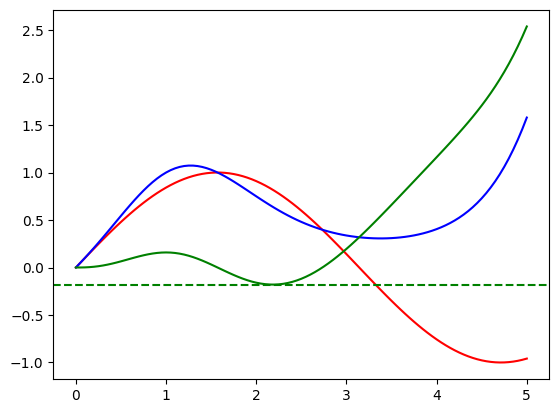

In [13]:
# do some vector computations
y1, y2 = x.sin(), x ** x.cos()
y3 = y2 - y1
y4 = y3.min()

# print and plot some answers
print(f'The shape of x is {x.shape}')
print(f'The shape of y1=x.sin() is {y1.shape}')
print(f'The shape of y2=x ** x.cos() is {y2.shape}')
print(f'The shape of y3=y2 - y1 is {y3.shape}')
print(f'The shape of y4=y3.min() is {y4.shape}, a zero-d scalar')

plt.plot(x, y1, 'red', x, y2, 'blue', x, y3, 'green')
plt.axhline(y4, color='green', linestyle='--')
plt.show()

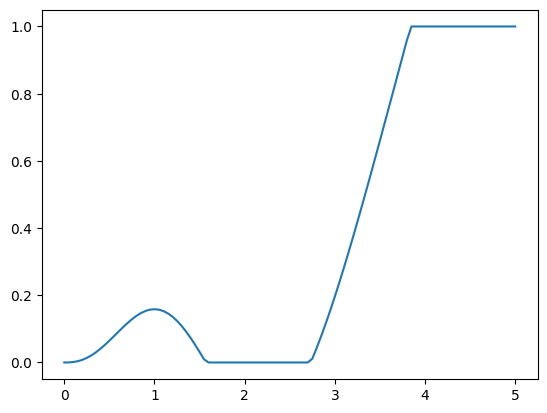

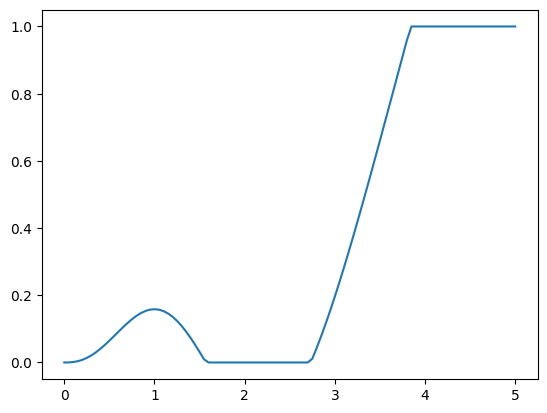

In [14]:
# plot y3 clamped between 0.0 and 1.0.

plt.plot(x, y3.clamp(0.0, 1.0))
plt.show()

y4 = y3.clamp(0.0, 1.0)
plt.plot(x, y4)
plt.show()


PyTorch Tensor Dimension-Ordering Conventions
---------------------------------------------

**Multidimensional data convention.** As soon as you have more than one dimension, you need to decide how to order the axes.  To reduce confusion, most data processing follows the same global convention. In particular, much image-related data in pytorch is four dimensional, and the dimensions are ordered like this: `data[batch_index, channel_index, y_position, x_position]`, that is:

* Dimension 0 is used to index separate images within a batch.
* Dimension 1 indexes channels within an image representation (e.g., 0,1,2 = R,G,B, or more dims for more channels).
* Dimension 2 (if present) indexes the row position (y-value, starting from the top)
* Dimension 3 (if present) indexes the column position (x-value, starting from the left)

There a way to remember this ordering: adjacent entries that vary only in the last dimensions are stored physically closer in RAM; since they are often combined with each other, this could help with locality, whereas the first (batch) dimension usually just groups separate independent data points which are not combined much, so they do not need to be physically close.

Stream-oriented data without grid geometry will drop the last dimensions, and 3d grid data will be 5-dimensional, adding a depth z before y.  This same 4d-axis ordering convention is also seen in caffe and tensorflow.

Separate tensors can be put together into a single batch tensor using `torch.cat([a, b, c])` or `torch.stack([a, b, c])`.  (The difference: `cat` doesn't add any new dimensions but just concatenates along the existing 0th dimension.  `stack` adds a new 0th dimension for the batch.)

**Multidimensional linear operation convention.** When storing matrix weights or convolution weights, linear algebra conventions are followed
* Dimension 0 (number of rows) matches the output channel dimension
* Dimension 1 (number of columns) matches the input channel dimension
* Dimension 2 (if present) is the convolutional kernel y-dimension
* Dimension 3 (if present) is the convolutional kernel x-dimension

Since this convention assumes channels are arranged in different rows whereas the data convention puts different batch items in different rows, some axis transposition is often needed before applying linear algebra to the data.

**Permute and view reshape an array without moving memory.** The `permute` and `view` methods are useful for rearranging, flattening, and unflatteneing axes. `x.permute(1,0,2,3).view(x.shape[1], -1)`.  They just alter the view of the block of numbers in memory without moving any of the numbers around, so they are fast.

**Reshaping sometimes needs copying.** Some sequences of axis permutations and flattenings cannot be done without copying the data into the new order in memory; the `x.contiguous()` method copies the data iinto the natural order given by the current view; also `x.reshape()` is similar to `view` but will makea copy if necessary so you do not need to think about it.  See [the Tensor.view method documentation](https://pytorch.org/docs/master/tensors.html#torch.Tensor.view).


In [17]:
# use torch.randn to create a four-dimensional tensor x of size (2, 3, 4, 5), which could store two 5x4 RGB images.
# then print x, the switch of the last 2 horizontal and vertical dimensions, and each image as a flat vector of 60 numbers

x = torch.randn((2, 3, 4, 5))
print(x.shape)

# permute dimensions
print(x.permute((0, 1, 3, 2)).shape)

# reshape
print(x.view(x.shape[0], -1).shape)

torch.Size([2, 3, 4, 5])
torch.Size([2, 3, 5, 4])
torch.Size([2, 60])


**Standard Numpy-like indexing and slicing**

In [18]:
tensor = torch.ones(4, 4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[:, -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


**Joining tensors** You can use `torch.cat` to concatenate a sequence of
tensors along a given dimension. See also
[torch.stack](https://pytorch.org/docs/stable/generated/torch.stack.html),
another tensor joining operator that is subtly different from
`torch.cat`.


In [19]:
t1  = torch.cat([tensor, tensor, tensor], dim=0) # concatanates along dimension
print(tensor)
print(tensor.shape)
print(t1)
print(t1.shape)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
torch.Size([4, 4])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
torch.Size([12, 4])


In [20]:
t2 = torch.stack([tensor, tensor, tensor], dim=1) # creates new dimension
print(tensor)
print(tensor.shape)
print(t2)
print(t2.shape)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
torch.Size([4, 4])
tensor([[[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]],

        [[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]],

        [[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]],

        [[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]]])
torch.Size([4, 3, 4])


**Empty Dimensions**

In [21]:
t3 = tensor.unsqueeze(0)
print(tensor.shape)
print(t3.shape)
print(t3)
t4 = t3.squeeze(0)
print(tensor.shape)
print(t4.shape)
print(t4)

torch.Size([4, 4])
torch.Size([1, 4, 4])
tensor([[[1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.],
         [1., 0., 1., 1.]]])
torch.Size([4, 4])
torch.Size([4, 4])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


**Arithmetic Operations**

In [22]:
# this computes the matrix multiplication between two tensors. y1, y2, y3 will have the same value
# ``tensor.T`` returns the transpose of a tensor
tensor = torch.Tensor([[1,2,5],[3,4,6]])
print(tensor.shape)

y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)
y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out=y3)
print(y1, y1.shape)
print(y2, y2.shape)
print(y3, y3.shape)

torch.Size([2, 3])
tensor([[30., 41.],
        [41., 61.]]) torch.Size([2, 2])
tensor([[30., 41.],
        [41., 61.]]) torch.Size([2, 2])
tensor([[30., 41.],
        [41., 61.]]) torch.Size([2, 2])


In [23]:
# this computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)
print(z1, z1.shape)
print(z2)
print(z3)

tensor([[ 1.,  4., 25.],
        [ 9., 16., 36.]]) torch.Size([2, 3])
tensor([[ 1.,  4., 25.],
        [ 9., 16., 36.]])
tensor([[ 1.,  4., 25.],
        [ 9., 16., 36.]])


**Single-element tensors** If you have a one-element tensor, for example
by aggregating all values of a tensor into one value, you can convert it
to a Python numerical value using `item()`:


In [24]:
agg = tensor.sum()
print(agg, type(agg), agg.dtype)
print(agg.shape)
agg_item = agg.item()
print(agg_item, type(agg_item))

tensor(21.) <class 'torch.Tensor'> torch.float32
torch.Size([])
21.0 <class 'float'>


# Special Topic: Einsum

Matrix multiplication can be generalized to tensors of arbitrary number of dimensions, but keeping tensor dimensions straight can be confusing. The solution to this is Einstein notation: assign letter variables to each axis of the input tensors, and then explicitly write down which axes end up in the output tensor. For example, an outer product might be written as i, j -> ij, whereas matrix multiplication could be ij, jk -> ik.

Einstein notation is a topic of active development and programming language design: [here is a recent paper on the history and future of Einstein APIs.](https://openreview.net/pdf?id=oapKSVM2bcj)

In pytorch, Einstein notation is available as einsum. Here is how ordinary matrix multiplication looks as einsum:

In [25]:
A = torch.randn(2,5)
B = torch.randn(5,3)

# Uncomment to see ordinary matrix multiplication
# print(torch.mm(A, B))

# ordinary matrix multiplication written as an einsum
print(torch.einsum('ij, jk -> ik', A, B))

tensor([[ 2.9750, -0.8490,  2.5206],
        [ 1.4232, -3.5677,  3.3720]])


# Special Topic: Broadcasting
Two tensors are “broadcastable” if the following rules hold:

*   Each tensor has at least one dimension.
*   When iterating over the dimension sizes, starting at the trailing dimension, the dimension sizes must either be equal, one of them is 1, or one of them does not exist.

If a PyTorch operation supports broadcast, then its Tensor arguments can be automatically expanded to be of equal sizes (without making copies of the data).

If two tensors x, y are “broadcastable”, the resulting tensor size is calculated as follows:

* If the number of dimensions of x and y are not equal, prepend 1 to the dimensions of the tensor with fewer dimensions to make them equal length.
* Then, for each dimension size, the resulting dimension size is the max of the sizes of x and y along that dimension.

More details are available [here](https://pytorch.org/docs/stable/notes/broadcasting.html)

In [31]:
x=torch.empty(5,7,3)
y=torch.empty(5,7,3)
# same shapes are always broadcastable (i.e. the above rules always hold)

x=torch.empty((0,))
y=torch.empty(2,2)
# x and y are not broadcastable, because x does not have at least 1 dimension

# can line up trailing dimensions
x=torch.empty(5,3,4,1)
y=torch.empty(  3,1,1)
# x and y are broadcastable.
# 1st trailing dimension: both have size 1
# 2nd trailing dimension: y has size 1
# 3rd trailing dimension: x size == y size
# 4th trailing dimension: y dimension doesn't exist

# but:
x=torch.empty(5,2,4,1)
y=torch.empty(  3,1,1)
# x and y are not broadcastable, because in the 3rd trailing dimension 2 != 3

In [32]:
# can line up trailing dimensions to make reading easier
x=torch.empty(5,1,4,1)
y=torch.empty(  3,1,1)
print((x+y).size())

# but not necessary:
x=torch.empty(1)
y=torch.empty(3,1,7)
print((x+y).size())

x=torch.empty(5,2,4,1)
y=torch.empty(3,1,1)
# print((x+y).size())

torch.Size([5, 3, 4, 1])
torch.Size([3, 1, 7])


Topic 2: Pytorch Autograd
================

If you flag a torch Tensor with the attribute `x.requires_grad=True`, then pytorch will automatically keep track the computational history of all tensors that are derived from `x`.  This allows pytorch to figure out derivatives of any scalar result with regard to changes in the components of x.

<img src="https://raw.githubusercontent.com/davidbau/how-to-read-pytorch/6ce891301e79aa8e2164a703c08257a52b2d1ad3/notebooks/autograd-graph.png" style="max-width:100%">

The function `torch.autograd.grad(output_scalar, [list of input_tensors])` computes `d(output_scalar)/d(input_tensor)` for each input tensor component in the list.  For it to work, the input tensors and output must be part of the same `requires_grad=True` compuation.

In the example here, `x` is explicitly marked `requires_grad=True`, so `y.sum()`, which is derived from `x`, automatically comes along with the computation history, and can be differentiated.